In [1]:
%matplotlib inline
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as nd

import astropy.io.fits as pyfits
import astropy.units as u

import sep

import grizli
from grizli import utils
print(f'grizli version: {grizli.__version__}')

import msaexp
import msaexp.spectrum
print(f'msaexp version: {msaexp.__version__}')

BASE_URL = 'https://s3.amazonaws.com/msaexp-nirspec/extractions/'
PATH_TO_FILE = BASE_URL + '{root}/{file}'

grizli version: 1.14.2
msaexp version: 0.9.17


In [2]:
from astropy.io import fits
from astropy import units as u
import numpy as np
from matplotlib import pyplot as plt
from astropy.visualization import quantity_support
quantity_support()  # for getting units on the axes below
from specutils import Spectrum

specs = msaexp.spectrum.get_spectra(
    file = "aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits", 
    sx=8, sy=2,
    ny=4, renorm = False
)

https://grizli-cutout.herokuapp.com/nirspec_extractions?file=aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits&output=csv
aurora-gdn02-v4_g140m-f100lp_1914_931951.spec.fits (True) 2.4832  grade=3
aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits (True) 2.4832  grade=3
aurora-gdn02-v4_g395m-f290lp_1914_931951.spec.fits (True) 2.4832  grade=3


(-5.0, 20.0)

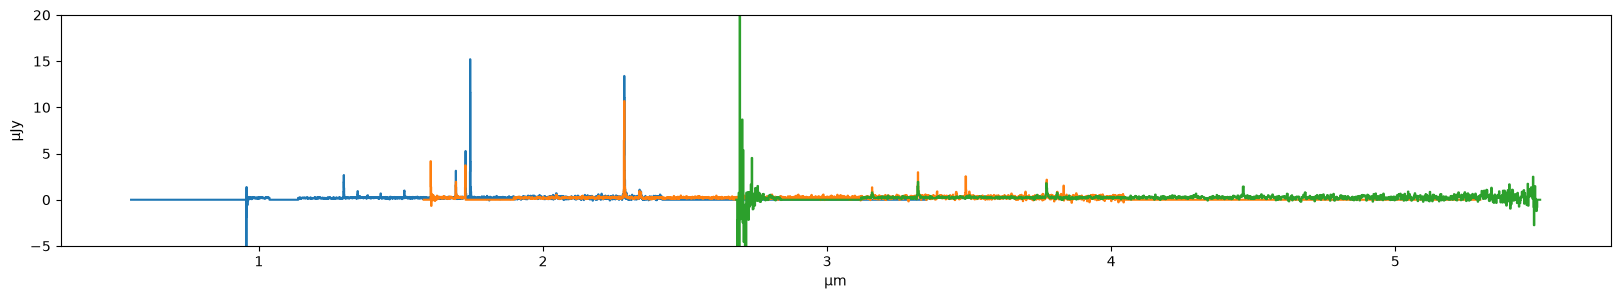

In [85]:
f, ax = plt.subplots(figsize = (20, 3))

for spec in specs:
    ax.step(spec.spectral_axis, spec.flux)
# ax.set_xlim(2.5, 3)
ax.set_ylim(-5, 20)

In [80]:
from astropy.table import QTable as qt

GF = ['g140m-f100lp', 'g235m-f170lp', 'g395m-f290lp']

delta_lambda_gf = {}
min_max_list = []

for spec, gf in zip(specs, GF):
    data = qt([spec.spectral_axis, spec.flux], names=('Spectral Axis', 'Flux'))
    l = data['Spectral Axis'].size 
    min_max = [data['Spectral Axis'].min().value, data['Spectral Axis'].max().value]
    delta = data['Spectral Axis'] -  data['Spectral Axis'][0]
    #print(delta)
    final = delta[-1]
    delta_lambda = delta[1]
    difference = delta_lambda * (l - 1) - final
    print(f'Delta {gf}: ' + str(difference.value))
    print(f'Cantidad de datos para {gf}: ' + str(l))
    print('')

    delta_lambda_gf[gf] = delta_lambda.value
    min_max_list.extend(min_max)

display(delta_lambda_gf)

minimum = min(min_max_list)
maximum = max(min_max_list)
print('Minimum - Maximum Wavelengths: ' + str(minimum) + ', ' + str(maximum))

delta_total = maximum - minimum

total_steps_delta = {k: delta_total/v for k, v in delta_lambda_gf.items()}
display(total_steps_delta)


Delta g140m-f100lp: 0.0
Cantidad de datos para g140m-f100lp: 4667

Delta g235m-f170lp: 0.0
Cantidad de datos para g235m-f170lp: 3685

Delta g395m-f290lp: 4.440892098500626e-16
Cantidad de datos para g395m-f290lp: 1661



{'g140m-f100lp': 0.0006000000000000449,
 'g235m-f170lp': 0.0010095238095237935,
 'g395m-f290lp': 0.0017047619047620977}

Minimum - Maximum Wavelengths: 0.55, 5.509904761905082


{'g140m-f100lp': 8266.50793650785,
 'g235m-f170lp': 4913.113207547565,
 'g395m-f290lp': 2909.4413407819816}

https://grizli-cutout.herokuapp.com/nirspec_extractions?file=aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits&output=csv
aurora-gdn02-v4_g140m-f100lp_1914_931951.spec.fits (True) 2.4832  grade=3
aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits (True) 2.4832  grade=3
aurora-gdn02-v4_g395m-f290lp_1914_931951.spec.fits (True) 2.4832  grade=3
aurora-gdn02-v4_g140m-f100lp_1914_931951.spec.fits  z=2.483  0.28 – 0.69 µm
aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits  z=2.483  0.46 – 1.16 µm
aurora-gdn02-v4_g395m-f290lp_1914_931951.spec.fits  z=2.483  0.79 – 1.58 µm


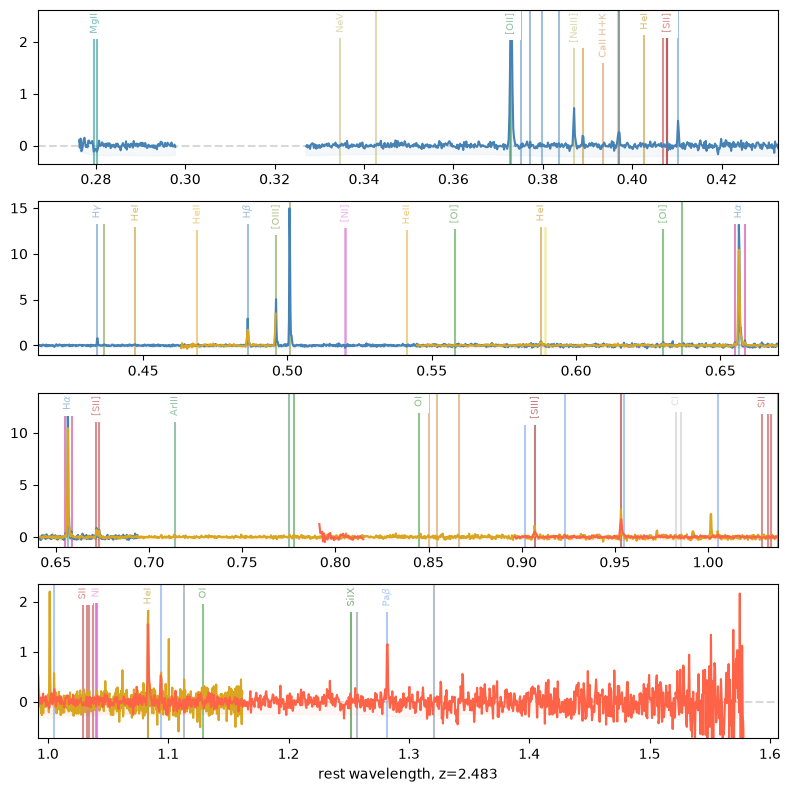

In [ ]:
from msaexp import spectrum
import msaexp.utils

result = spectrum.multiplot_spectra(
    file="aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits",
    sx=8, sy=2,
    ny=4, renorm = False
)

# Overplot line list
li = msaexp.utils.lines.LineList()
for ax in result['axes']:
    li.add_to_axis(ax, alpha=0.5)

result['axes'][-1].set_xlabel(
    f"rest wavelength, z={result['z']:.3f}"
)

result['fig'].tight_layout(pad=1)